In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import extra_functions as ef
import h5py
import importlib
from skyfield.api import load, EarthSatellite, Topos, wgs84
from scipy.ndimage import label as splabel
from scipy.interpolate import interp1d
from numpy.polynomial import Polynomial

BDC is using numpy


In [ ]:
def roll_poly(phase, fit_window=50, p_deg=3):
    N = len(phase)
    t = np.arange(N)

    res_sum = np.zeros(N)
    res_sum_sq = np.zeros(N)
    count = np.zeros(N)

    for i in range(N - fit_window + 1):
        idx = slice(i, i + fit_window)
        t_win = t[idx]
        y_win = phase[idx]

        #model by polynomial by rolling window
        try:
            pfit = Polynomial.fit(t_win, y_win, deg=p_deg)
            y_fit = pfit(t_win)
            res = y_win - y_fit

            res_sum[idx] += res
            res_sum_sq[idx] += res ** 2
            count[idx] += 1

        except:
            continue  

    count[count == 0] = 1
    res_avg = res_sum / count
    var = (res_sum_sq / count) - res_avg ** 2
    var[var < 0] = 0 
    local_std = np.sqrt(var)

    return local_std
    


def cut_mask(mask):
    #want the longest continuous strip of good data
    #which involves cutting the mask

    mask_int = mask.astype(int)
    diff = np.diff(mask_int)

    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0] + 1

    if mask[0]:
        starts = np.r_[0, starts]
    if mask[-1]:
        ends = np.r_[ends, len(mask)]

    lengths = ends - starts
    if len(lengths) == 0:
        return None, None, np.zeros_like(mask, dtype=bool)

    max_idx = np.argmax(lengths)
    start, end = starts[max_idx], ends[max_idx]
    segment_mask = np.zeros_like(mask, dtype=bool)
    segment_mask[start:end] = True

    return start, end, segment_mask


def interp_bumps(data, interp_mask, max_gap):
    labeled, num = splabel(interp_mask)
    data_filled = np.copy(data)

    for i in range(1, num + 1):
        indices = np.where(labeled == i)[0]
        if len(indices) <= max_gap:
            start = indices[0]
            end = indices[-1] + 1

            left = start - 1
            right = end

            if left >= 0 and right < len(data) and mask[left] and mask[right]:
                f = interp1d([left, right], [data[left], data[right]])
                data_filled[start:end] = f(np.arange(start, end))
                interp_mask[start:end] = True

    return data_filled, interp_mask


def roll_curve(phase, window_size=40):
    diff2 = np.diff(np.diff(phase))  # second derivative
    curve_rms = np.zeros(len(phase))
    count = np.zeros(len(phase))

    for i in range(len(diff2) - window_size + 1):
        idx = slice(i, i + window_size)
        local_rms = np.sqrt(np.mean(diff2[idx]**2))

        center = i + window_size // 2
        curve_rms[center] += local_rms
        count[center] += 1

    count[count == 0] = 1
    curve_rms = curve_rms / count

    return curve_rms



In [3]:
day = '07_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_23'

with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]

ref_coords = coords[0]
a2_coords = coords[1]
v_nchunks = int((visibility_window)/(v_acclen* T_SPECTRA))

context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(context)
print(global_start_time)


[1000, 1.6384e-05, 30000, 2034, [79.41718333333333, -90.76735, 189]]
1699335012


In [4]:
pl = []

with h5py.File(f'{working_directory}/{bits}bit/{day}/visraw_bline{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p) #index 0
        pulse_info.append([int(f[p].attrs['start_time']), int(f[p].attrs['end_time']), int(f[p].attrs['global_start_time'])]) # index 1
        pulse_info.append(json.loads(f[p].attrs['sats'])) #index 2
        #pulse_info.append(f[p].attrs['tle_path']) #index 3
        pulse_info.append(outils.get_tle_file(int(f[p].attrs['global_start_time']) + int(f[p].attrs['start_time']), "/project/s/sievers/mohanagr/OCOMM_TLES"))
        pulse_info.append(f[f'/{p}'][:])  # index 4
        pl.append(pulse_info)

print(len(pl))

#note on ordering of the pulse_data list:
# example entry:   [[relative_start_time, relative_end_time, global_start_time], {satID:[chan1, chan2]}, tle_path, [observed data array]]

39


3
20_54845
[54845, 55380, 1699335012]
57166
[1836, 1837]
/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231107.txt


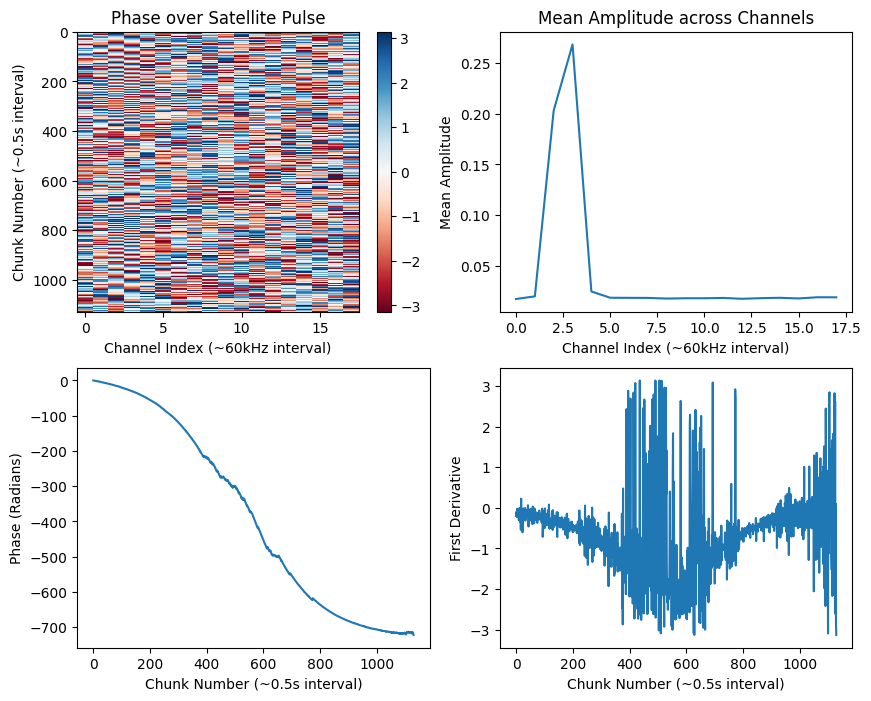

In [5]:
pulse_idx = 12
label = pl[pulse_idx][0]
times = pl[pulse_idx][1]
vis = pl[pulse_idx][4]
satID = int(list(pl[pulse_idx][2].keys())[0])  #for now only worry about one satellite
channels_present = list(pl[pulse_idx][2].values())[0]
tle_path = pl[pulse_idx][3]

#here I might want to interpolate in v2?

p_vis = np.angle(vis)
amp = np.abs(vis)

mean_amp = []
for i in range(18):
    mean_amp.append(np.mean(amp[:,i]))

chan_small_idx = np.where(mean_amp == np.max(mean_amp))[0][0]
print(chan_small_idx)

phase = np.unwrap(p_vis[:,chan_small_idx])
diff = np.diff(phase)


print(label)
print(times)
print(satID)
print(channels_present)
print(tle_path)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
ax[0,0].set_xlabel("Channel Index (~60kHz interval)")
ax[0,0].set_ylabel("Chunk Number (~0.5s interval)")
ax[0,0].set_title("Phase over Satellite Pulse")
im = ax[0,0].imshow(p_vis, aspect='auto', cmap='RdBu', interpolation="none")
fig.colorbar(im)

ax[0,1].set_xlabel("Channel Index (~60kHz interval)")
ax[0,1].set_ylabel("Mean Amplitude")
ax[0,1].set_title("Mean Amplitude across Channels")
ax[0,1].plot(mean_amp)

ax[1,0].set_xlabel("Chunk Number (~0.5s interval)")
ax[1,0].set_ylabel("Phase (Radians)")
ax[1,0].plot(phase)

ax[1,1].set_xlabel("Chunk Number (~0.5s interval)")
ax[1,1].set_ylabel("First Derivative")
ax[1,1].plot(diff)



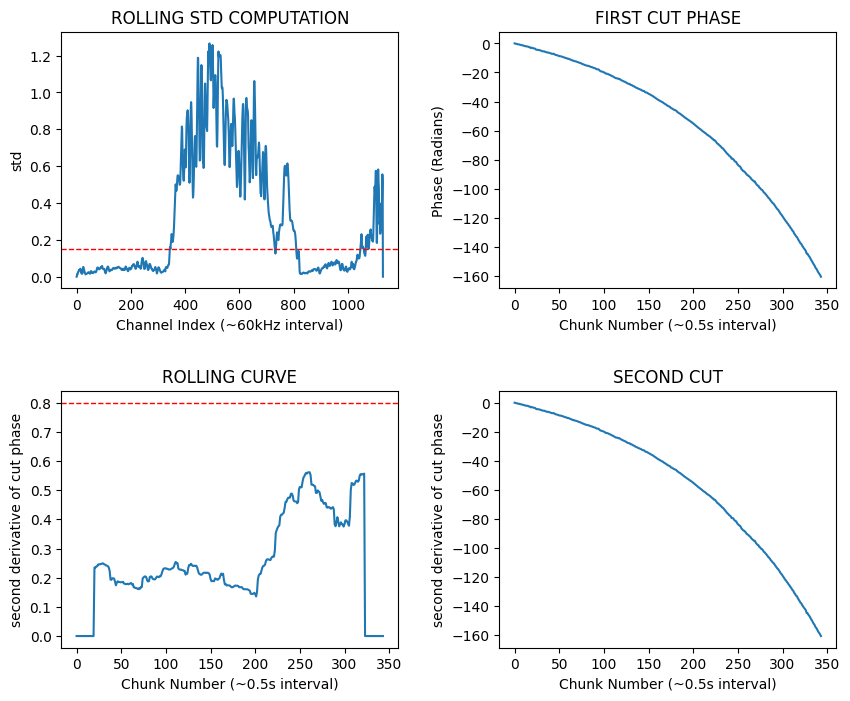

In [6]:
'''
It's good that I have this method of cutting, since it takes both into account.
The only thing is how do I want to interpolate? Between the first and second cuts? Or somewhere else?
'''


std_tol = 0.15
roll_tol = 0.8   #check this is the right value! (do testing)

std = roll_poly(phase)
mask = std < std_tol 

start, end, _ = cut_mask(mask)
cut_phase = phase[start:end]

curve = roll_curve(cut_phase)
curve_mask = curve < roll_tol     
mask[start:end] &= curve_mask  

start_final, end_final, final_mask = cut_mask(mask) #get longest continuous value where this works
silent_phase = phase[start_final:end_final]

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
plt.subplots_adjust(hspace=0.4, wspace = 0.3)

ax[0,0].set_xlabel("Channel Index (~60kHz interval)")
ax[0,0].set_ylabel("std")
ax[0,0].set_title("ROLLING STD COMPUTATION")
ax[0,0].plot(std)
ax[0,0].axhline(y=std_tol, color='red', linestyle='--', linewidth=1)

ax[0,1].set_xlabel("Chunk Number (~0.5s interval)")
ax[0,1].set_ylabel("Phase (Radians)")
ax[0,1].set_title("FIRST CUT PHASE")
ax[0,1].plot(cut_phase)

ax[1,0].set_xlabel("Chunk Number (~0.5s interval)")
ax[1,0].set_ylabel("second derivative of cut phase")
ax[1,0].set_title("ROLLING CURVE")
ax[1,0].plot(curve)
ax[1,0].axhline(y=roll_tol, color='red', linestyle='--', linewidth=1)

ax[1,1].set_xlabel("Chunk Number (~0.5s interval)")
ax[1,1].set_ylabel("second derivative of cut phase")
ax[1,1].set_title("SECOND CUT")
ax[1,1].plot(silent_phase)



if len(cut_phase) < 150:
    print("THROW AWAY")

In [7]:
good_pulse_data = []
std_tol = 0.15
roll_tol = 0.6
channel_list = np.arange(1834, 1852, dtype=int)

for pulse in pl:
    pi = []

    #unpack
    label = pulse[0]
    rel_s_time, global_start_time = pulse[1][0], pulse[1][2]
    satID = int(list(pulse[2].keys())[0])  #for now only worry about one satellite
    channels_present = list(pulse[2].values())[0]
    tle_path = pulse[3]
    vis = pulse[4]
    
    amp = np.abs(vis)
    mean_amp = []
    for i in range(18):
        mean_amp.append(np.mean(amp[:,i]))

    chan_small_idx = np.where(mean_amp == np.max(mean_amp))[0][0]
    chan_big_idx = channel_list[chan_small_idx]
    phase = np.unwrap(np.angle(vis[:,chan_small_idx]))

    std = roll_poly(phase)
    mask = std < std_tol 

    start, end, _ = cut_mask(mask)
    cut_phase = phase[start:end]

    curve = roll_curve(cut_phase)
    curve_mask = curve < roll_tol     
    mask[start:end] &= curve_mask  

    start_final, end_final, final_mask = cut_mask(mask) #get longest continuous value where this works
    silent_phase = phase[start_final:end_final]

    start_s = start_final * (context[2]*context[1]) + rel_s_time
    end_s = end_final * (context[2]*context[1]) + rel_s_time

    if end_final - start_final < 200:
        continue

    pi.append(label)
    pi.append([start_s, end_s, times[2]])
    pi.append([satID, chan_big_idx])
    pi.append(tle_path)
    pi.append(vis[start_final:end_final, :])
    print(vis[start_final:end_final, :].shape)

    good_pulse_data.append(pi)

(248, 18)
(388, 18)
(222, 18)
(452, 18)
(337, 18)
(344, 18)
(279, 18)
(324, 18)
(286, 18)
(241, 18)
(281, 18)


(692, 18)
(206, 18)
(800, 18)
(232, 18)
(297, 18)
(542, 18)
(625, 18)
(223, 18)
(241, 18)
(672, 18)
(910, 18)
(807, 18)
(525, 18)
(525, 18)
(577, 18)


In [9]:
print(len(good_pulse_data))

26


15_46240
time for one delay pred: 0.016902685165405273
time taken pred 0.01702260971069336


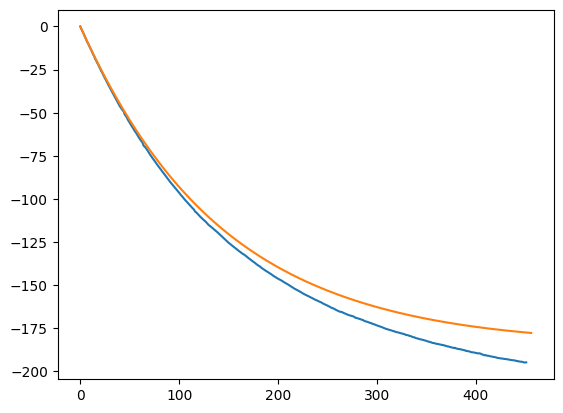

In [12]:
idx = 3
print(good_pulse_data[idx][0])
data = good_pulse_data[idx][4]
channel = np.where(channel_list == good_pulse_data[idx][2][1])[0][0]

angle = np.angle(data[:, channel])
phase = np.unwrap(angle) - angle[0]
pred = ef.pred(a2_coords, 0, idx, good_pulse_data, context)

plt.plot(phase)
plt.plot(pred)
